# TropiCycloneNet — Tropical Cyclone Track & Intensity Prediction

This notebook implements **three progressively richer models** for 24-hour tropical cyclone forecasting:

| Model | Inputs | Purpose |
|---|---|---|
| **Baseline** | Data_1d only (LON, LAT, P, W) | Lower bound |
| **Baseline + Env** | Data_1d + Env-Data | Test value of pre-computed physics features |
| **Full Multimodal** | Data_1d + Env-Data + Data_3d (SST, Z, U, V) | Full fusion model |

Each model predicts **both** `future_direction24` (8-class track) and `future_inte_change24` (4-class intensity) via a shared encoder with dual heads.

## 1. Imports & Configuration

In [2]:
import os, glob, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from netCDF4 import Dataset as ncDataset
from natsort import natsorted

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── paths ──
BASE_PATH = os.path.abspath(os.path.dirname('__file__'))  # notebook directory
PATH_1D   = os.path.join(BASE_PATH, 'TCND_Data1D', 'Data1D')
PATH_3D   = os.path.join(BASE_PATH, 'TCND_Data3D_WP', 'WP')
PATH_ENV  = os.path.join(BASE_PATH, 'TCND_Env-Data', 'Env-Data')
SAVE_DIR  = os.path.join(BASE_PATH, 'classification', 'saved_models')
os.makedirs(SAVE_DIR, exist_ok=True)

AREA = 'WP'  # Western Pacific (only basin with Data_3d)

# verify paths
for p, name in [(PATH_1D, 'Data_1d'), (PATH_3D, 'Data_3d'), (PATH_ENV, 'Env-Data')]:
    print(f'{name}: {"OK" if os.path.isdir(p) else "MISSING"} — {p}')

# ── Global normalization constants for Data_3d ──
# Pre-computed across all training files (1950-2016, 14276 .nc files).
# Channels: sst(1) + z(4 pressure levels) + u(4) + v(4) = 13
# Each pressure level is normalized independently — this is critical because
# z @ 200 hPa (~121,000 gpm) and z @ 925 hPa (~7,400 gpm) live on completely
# different scales. Without per-level normalization the CNN cannot learn
# meaningful spatial patterns at each atmospheric layer.
CHANNEL_MEANS = np.array([
    262.4888,     # sst (Kelvin; mean < 300 because land pixels = 0)
    121820.5777,  # z @ 200 hPa  (upper troposphere — outflow layer)
    57228.5285,   # z @ 500 hPa  (mid-troposphere — steering flow)
    14520.6944,   # z @ 850 hPa  (boundary layer)
    7374.3746,    # z @ 925 hPa  (near-surface boundary layer)
    1.8846,       # u @ 200 hPa
    1.2516,       # u @ 500 hPa
    -0.1519,      # u @ 850 hPa
    -0.8776,      # u @ 925 hPa
    1.0121,       # v @ 200 hPa
    2.1861,       # v @ 500 hPa
    1.8612,       # v @ 850 hPa
    1.4980,       # v @ 925 hPa
], dtype=np.float32)

CHANNEL_STDS = np.array([
    99.7658,      # sst
    1067.0218,    # z @ 200 hPa
    640.2119,     # z @ 500 hPa
    426.5352,     # z @ 850 hPa
    422.2209,     # z @ 925 hPa
    14.9477,      # u @ 200 hPa
    9.0929,       # u @ 500 hPa
    8.4176,       # u @ 850 hPa
    8.1730,       # u @ 925 hPa
    9.8087,       # v @ 200 hPa
    6.8912,       # v @ 500 hPa
    7.1467,       # v @ 850 hPa
    7.5028,       # v @ 925 hPa
], dtype=np.float32)

# Reshape for broadcasting: (13, 1, 1) to apply over (81, 81) spatial dims
CHANNEL_MEANS_T = torch.from_numpy(CHANNEL_MEANS).view(13, 1, 1)
CHANNEL_STDS_T  = torch.from_numpy(CHANNEL_STDS).view(13, 1, 1)

Using device: cuda
Data_1d: OK — c:\Users\danie\Desktop\Tropical Cyclones\TCND_Data1D\Data1D
Data_3d: OK — c:\Users\danie\Desktop\Tropical Cyclones\TCND_Data3D_WP\WP
Env-Data: OK — c:\Users\danie\Desktop\Tropical Cyclones\TCND_Env-Data\Env-Data


## 1.5 Data Exploration

Understanding the dataset before modelling: class distributions, cyclone track patterns, and atmospheric field visualizations.

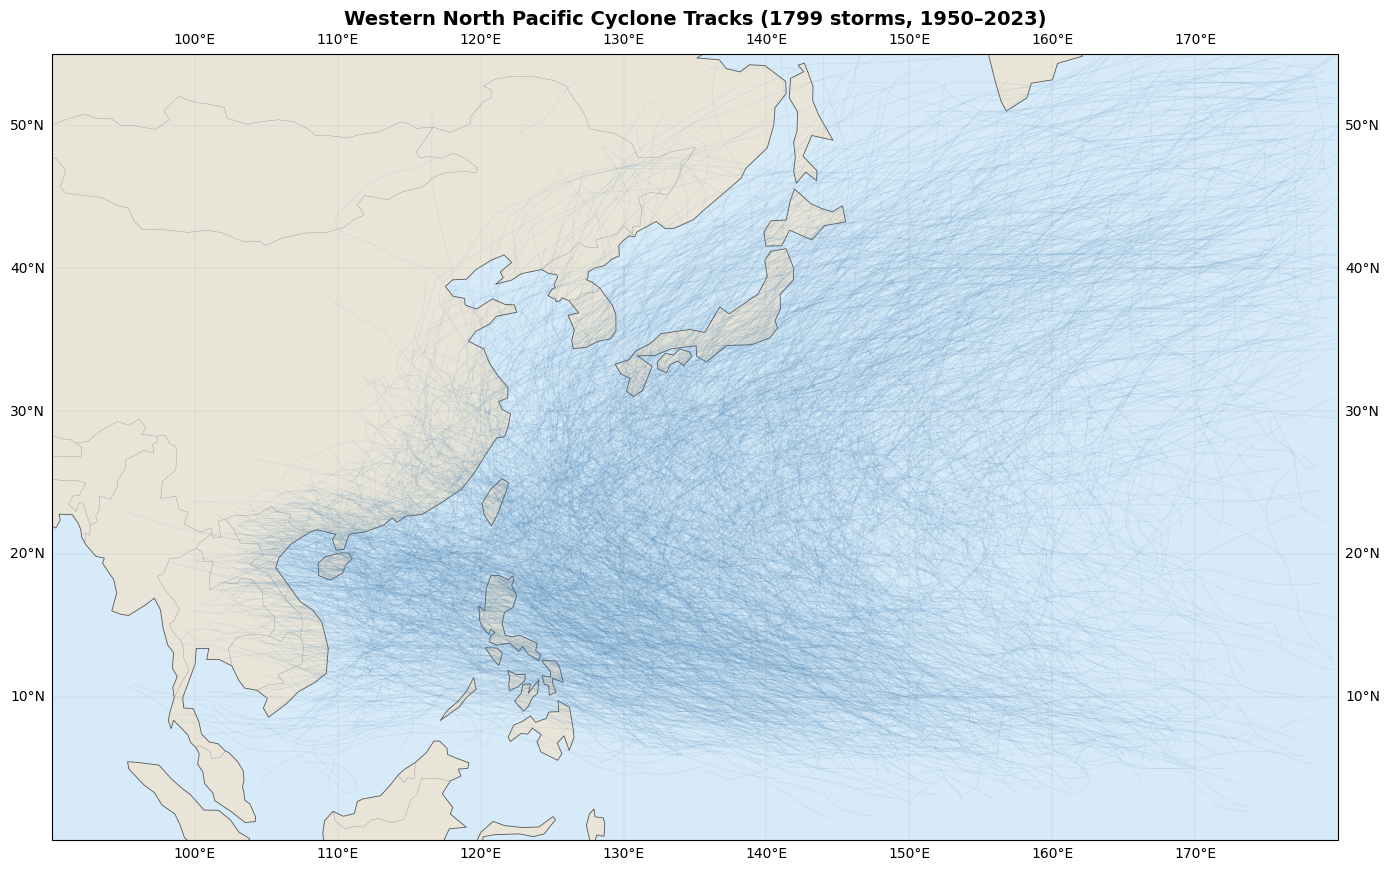

Plotted 1799 cyclone tracks on cartopy map.
Denormalization: LON_deg = LON_norm × 5 + 180, LAT_deg = LAT_norm × 5


In [5]:
# ── 1.5a: Cyclone Track Map (Data_1d) with geographic background ──
# Denormalization: LON_deg = LON_norm * 5 + 180, LAT_deg = LAT_norm * 5
# Verified by cross-referencing with Env-Data location tuples.

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not installed — run: pip install cartopy")
    print("Falling back to plain matplotlib with approximate coastlines.")

if HAS_CARTOPY:
    fig = plt.figure(figsize=(14, 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([90, 180, 0, 55], crs=ccrs.PlateCarree())

    # Map features
    ax.add_feature(cfeature.LAND, facecolor='#e8e4d8', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='#555555', zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, color='#999999', zorder=1)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5,
                 xlocs=range(90, 185, 10), ylocs=range(0, 60, 10))
else:
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(90, 180)
    ax.set_ylim(0, 55)
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    ax.set_ylabel('Latitude (°N)', fontsize=12)
    ax.grid(True, alpha=0.3)

track_count = 0
for split in ['train', 'val', 'test']:
    path = os.path.join(PATH_1D, AREA, split)
    for f in glob.glob(os.path.join(path, '*.txt')):
        df = pd.read_csv(f, delimiter='\t', header=None,
                         names=['ID', 'FLAG', 'LON', 'LAT', 'P', 'W', 'TIME', 'Name'])
        lon_deg = df['LON'].values * 5 + 180
        lat_deg = df['LAT'].values * 5
        if HAS_CARTOPY:
            ax.plot(lon_deg, lat_deg, alpha=0.2, linewidth=0.6, color='#FF4500',
                    transform=ccrs.PlateCarree(), zorder=2)
        else:
            ax.plot(lon_deg, lat_deg, alpha=0.2, linewidth=0.6, color='#FF4500', zorder=2)
        track_count += 1

ax.set_title(f'Western North Pacific Cyclone Tracks ({track_count} storms, 1950–2023)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'track_map.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'Plotted {track_count} cyclone tracks on {"cartopy map" if HAS_CARTOPY else "plain axes"}.')
print('Denormalization: LON_deg = LON_norm × 5 + 180, LAT_deg = LAT_norm × 5')

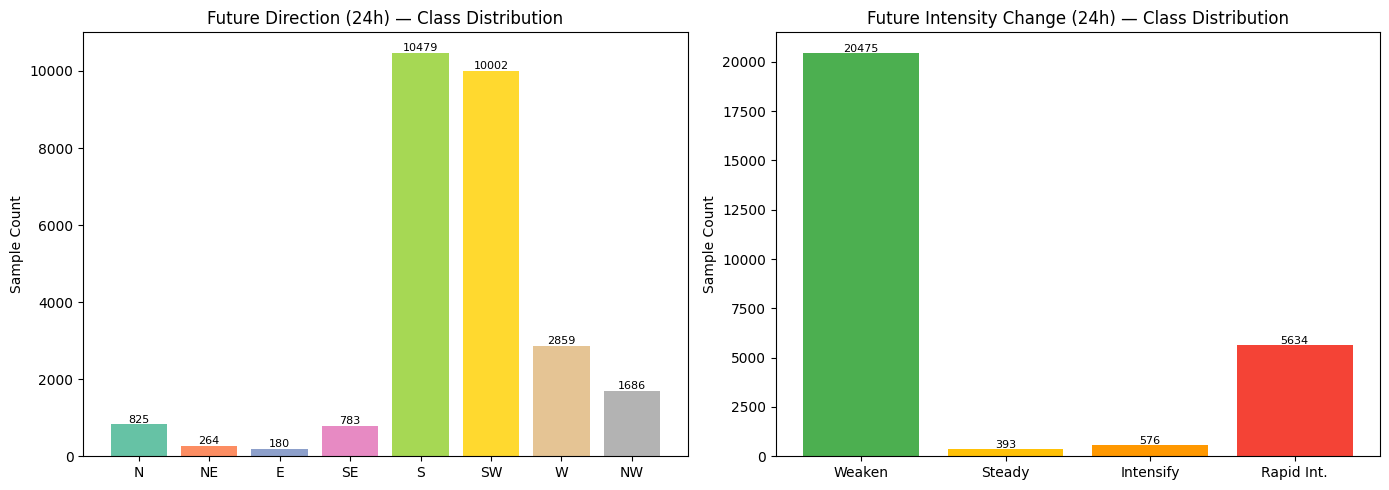

Direction: S and SW dominate — most WP cyclones move westward.
Intensity: Weaken and Intensify are common; Steady and Rapid Int. are rare.


In [9]:
# ── 1.5b: Class Distributions (from Env-Data) ──
# Shows why some directions are harder to predict — severe class imbalance.
dir_counts = np.zeros(8)
int_counts = np.zeros(4)

for split in ['train', 'val', 'test']:
    env_base = os.path.join(PATH_ENV, AREA)
    for year_dir in sorted(glob.glob(os.path.join(env_base, '*'))):
        for cyc_dir in glob.glob(os.path.join(year_dir, '*')):
            for npy_f in glob.glob(os.path.join(cyc_dir, '*.npy'))[:5]:  # sample per cyclone
                try:
                    d = np.load(npy_f, allow_pickle=True).item()
                    dl = d.get('future_direction24', None)
                    il = d.get('future_inte_change24', None)
                    if dl is not None and 0 <= int(dl) < 8:
                        dir_counts[int(dl)] += 1
                    if il is not None and 0 <= int(il) < 4:
                        int_counts[int(il)] += 1
                except:
                    pass

DIR_NAMES = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
INT_NAMES = ['Weaken', 'Steady', 'Intensify', 'Rapid Int.']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Direction distribution
colors_dir = plt.cm.Set2(np.linspace(0, 1, 8))
bars1 = ax1.bar(DIR_NAMES, dir_counts, color=colors_dir)
ax1.set_title('Future Direction (24h) — Class Distribution')
ax1.set_ylabel('Sample Count')
for bar, count in zip(bars1, dir_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(count)}', ha='center', fontsize=8)

# Intensity distribution
colors_int = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
bars2 = ax2.bar(INT_NAMES, int_counts, color=colors_int)
ax2.set_title('Future Intensity Change (24h) — Class Distribution')
ax2.set_ylabel('Sample Count')
for bar, count in zip(bars2, int_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(count)}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'class_distributions.png'), dpi=150)
plt.show()
print(f'Direction: S and SW dominate — most WP cyclones move westward.')
print(f'Intensity: Weaken and Intensify are common; Steady and Rapid Int. are rare.')

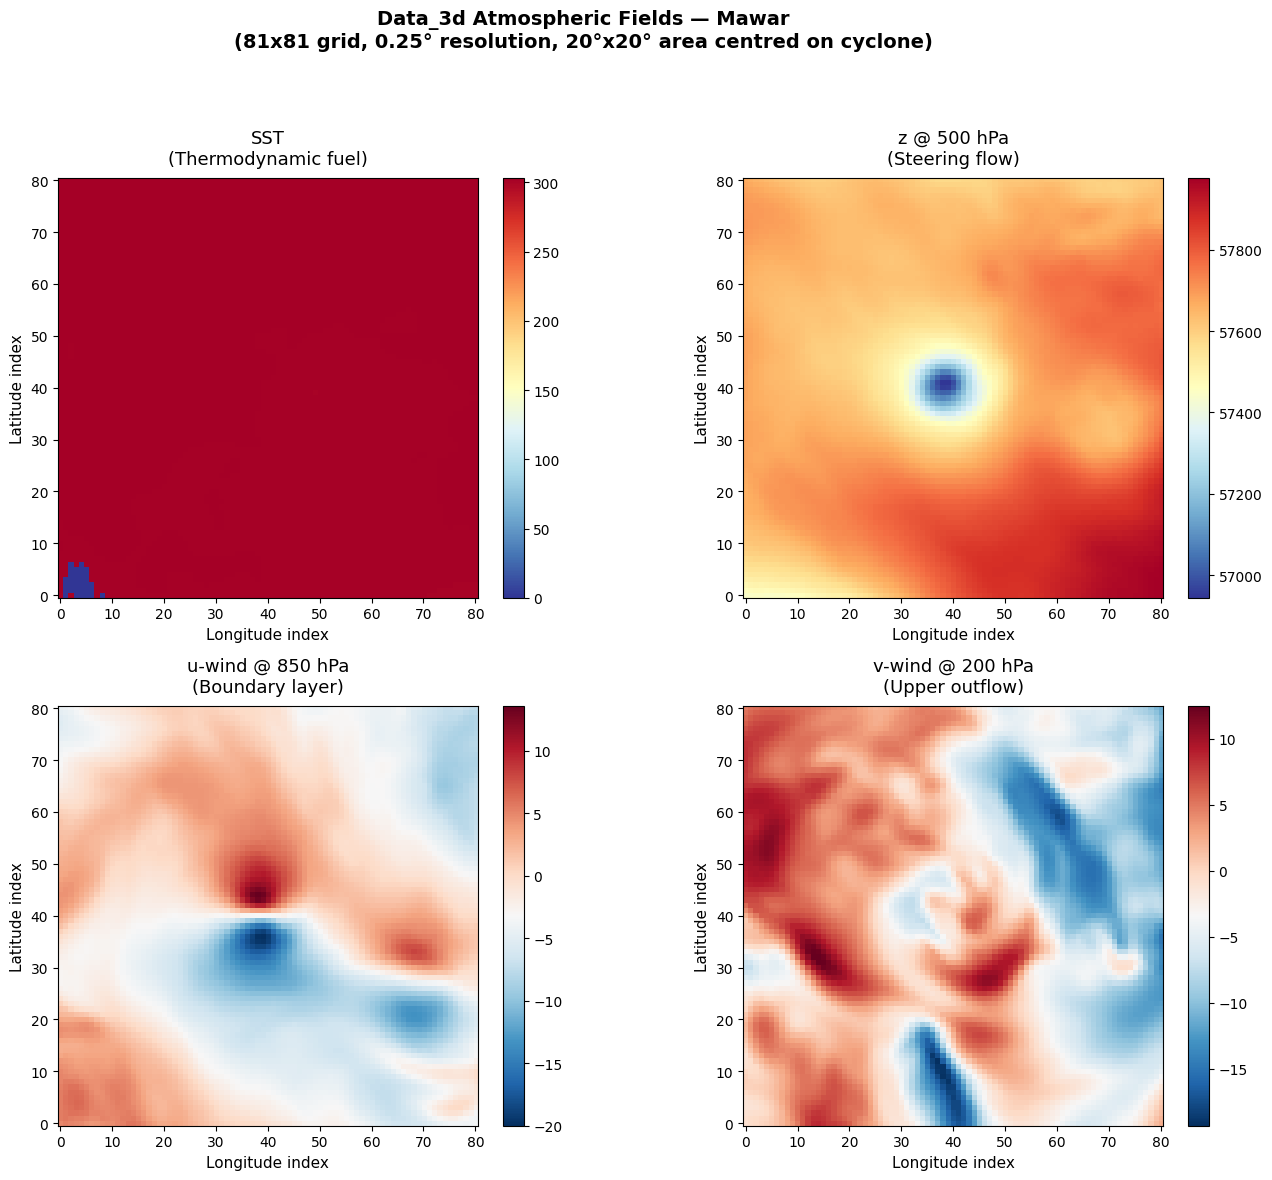

Each 81x81 grid covers a 20°x20° area centred on the cyclone.
The CNN processes all 13 channels simultaneously to extract atmospheric features.


In [4]:
# ── 1.5c: Sample Data_3d Atmospheric Fields ──
# Visualize what the CNN "sees" — one timestep of a cyclone.
sample_nc = glob.glob(os.path.join(PATH_3D, '2005', '*', '*.nc'))
if not sample_nc:
    sample_nc = glob.glob(os.path.join(PATH_3D, '2005', '*', '*_cache.npy'))

if sample_nc:
    nc_path = sample_nc[len(sample_nc)//2]  # pick a middle file
    if nc_path.endswith('.npy'):
        frame = np.load(nc_path)
    else:
        frame = _load_nc_frame(nc_path)
    
    # Show 4 key channels: SST, z@500 (steering), u@850 (boundary wind), v@200 (outflow)
    key_channels = [0, 2, 7, 9]
    key_names = ['SST\n(Thermodynamic fuel)', 'z @ 500 hPa\n(Steering flow)',
                 'u-wind @ 850 hPa\n(Boundary layer)', 'v-wind @ 200 hPa\n(Upper outflow)']
    cmaps = ['RdYlBu_r', 'RdYlBu_r', 'RdBu_r', 'RdBu_r']
    
    cyclone_name = os.path.basename(os.path.dirname(nc_path))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Data_3d Atmospheric Fields — {cyclone_name}\n(81x81 grid, 0.25° resolution, 20°x20° area centred on cyclone)',
                 fontsize=14, fontweight='bold')
    
    for ax, ch_idx, name, cmap in zip(axes.flatten(), key_channels, key_names, cmaps):
        im = ax.imshow(frame[ch_idx], cmap=cmap, origin='lower', aspect='equal')
        ax.set_title(name, fontsize=13, pad=10)
        ax.set_xlabel('Longitude index', fontsize=11)
        ax.set_ylabel('Latitude index', fontsize=11)
        ax.tick_params(labelsize=10)
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=10)
    
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(os.path.join(SAVE_DIR, 'sample_data3d.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print('Each 81x81 grid covers a 20°x20° area centred on the cyclone.')
    print('The CNN processes all 13 channels simultaneously to extract atmospheric features.')
else:
    print('No Data_3d files found for visualization.')

## 2. Dataset Classes

In [5]:
# ── Constants for Env-Data vector assembly ──
# When an Env-Data field is -1 (not enough history), we replace with zeros.
ENV_VECTOR_DIM = 87  # area(6)+intensity_class(6)+month(12)+location_long(36)+location_lat(12)+wind(1)+move_velocity(1)+hist_dir12(8)+hist_dir24(8)+hist_inte24(4) - but subtract location tuple = 87 total
# Actual breakdown: 6+6+12+36+12+1+1+8+8+4 = 94 ... let's compute it precisely below.

def _env_to_vector(env_dict):
    """Convert an Env-Data dict to a fixed-size float vector.
    
    Handles the -1 sentinel for missing history by replacing with zeros.
    Returns: np.array of shape (ENV_VEC_DIM,)
    """
    parts = []
    
    # Cyclone attributes
    parts.append(np.asarray(env_dict['area'], dtype=np.float32))            # (6,)
    parts.append(np.asarray(env_dict['intensity_class'], dtype=np.float32)) # (6,)
    parts.append(np.asarray(env_dict['month'], dtype=np.float32))           # (12,)
    
    # Location (one-hot encoded)
    parts.append(np.asarray(env_dict['location_long'], dtype=np.float32))   # (36,)
    parts.append(np.asarray(env_dict['location_lat'], dtype=np.float32))    # (12,)
    
    # Scalars
    wind = float(env_dict['wind']) if not isinstance(env_dict['wind'], np.ndarray) else float(env_dict['wind'])
    mv = float(env_dict['move_velocity']) if not isinstance(env_dict['move_velocity'], np.ndarray) else float(env_dict['move_velocity'])
    parts.append(np.array([wind, mv], dtype=np.float32))                    # (2,)
    
    # History (may be -1 sentinel → zeros)
    for key, size in [('history_direction12', 8), ('history_direction24', 8), ('history_inte_change24', 4)]:
        val = env_dict[key]
        if isinstance(val, (int, float, np.integer)) and val == -1:
            parts.append(np.zeros(size, dtype=np.float32))
        else:
            parts.append(np.asarray(val, dtype=np.float32).flatten()[:size])
    
    return np.concatenate(parts)  # total: 6+6+12+36+12+2+8+8+4 = 94

ENV_VEC_DIM = 94  # verified above
print(f'Env-Data vector dimension: {ENV_VEC_DIM}')

Env-Data vector dimension: 94


In [6]:
def _nc_exists(nc_path):
    """Check if a NetCDF file or its cached .npy version exists."""
    return os.path.exists(nc_path) or os.path.exists(nc_path.replace('.nc', '_cache.npy'))


def _load_nc_frame(nc_path):
    """Load one NetCDF timestep and return a (13, 81, 81) numpy array.
    
    Caches the result as a .npy file next to the .nc file so subsequent
    loads are ~10x faster (numpy mmap vs NetCDF parsing).
    """
    cache_path = nc_path.replace('.nc', '_cache.npy')
    if os.path.exists(cache_path):
        return np.load(cache_path)
    
    with ncDataset(nc_path) as nc:
        sst = np.ma.filled(nc.variables['sst'][:, :], fill_value=0.0)
        z   = np.ma.filled(nc.variables['z'][0, :, :, :], fill_value=0.0)
        u   = np.ma.filled(nc.variables['u'][0, :, :, :], fill_value=0.0)
        v   = np.ma.filled(nc.variables['v'][0, :, :, :], fill_value=0.0)
    frame = np.concatenate([sst[np.newaxis], z, u, v], axis=0).astype(np.float32)
    np.save(cache_path, frame)
    return frame


class CycloneDataset(Dataset):
    """Multi-modal dataset for TC prediction.
    
    Modes (controlled by `use_3d` and `use_env`):
      - Data_1d always loaded  (LON, LAT, P, W per timestep)
      - Env-Data optionally loaded (94-dim vector per timestep)
      - Data_3d optionally loaded  (13 channels x 81 x 81 per timestep)
    
    Labels come from Env-Data: future_direction24 (8-class) and future_inte_change24 (4-class).
    
    `splits` can be a list of directories to scan (e.g. ['train', 'val']) to
    combine data from multiple pre-split folders when doing temporal splitting.
    """

    # Data_3d channels: sst(1) + z(4) + u(4) + v(4) = 13
    NUM_3D_CHANNELS = 13

    def __init__(self, area=AREA, splits='train', target_years=None,
                 seq_len=5, use_env=False, use_3d=False):
        self.seq_len = seq_len
        self.use_env = use_env
        self.use_3d = use_3d
        self.samples = []

        # Support scanning multiple split directories
        if isinstance(splits, str):
            splits = [splits]

        files = []
        for split in splits:
            path_1d = os.path.join(PATH_1D, area, split)
            files.extend(natsorted(glob.glob(os.path.join(path_1d, '*.txt'))))

        for f in files:
            # Parse year from filename (e.g. WP2018BSTMANGKHUT.txt -> 2018)
            basename = os.path.basename(f)
            try:
                year = int(basename[2:6])
            except (ValueError, IndexError):
                continue
            if target_years and year not in target_years:
                continue

            df = pd.read_csv(f, delimiter='\t', header=None,
                             names=['ID', 'FLAG', 'LON', 'LAT', 'P', 'W', 'TIME', 'Name'])
            if len(df) < seq_len + 1:
                continue

            cyclone_name = str(df.iloc[0]['Name']).strip()

            for i in range(seq_len - 1, len(df) - 1):
                curr_seq = df.iloc[i - seq_len + 1: i + 1]
                timestamps = [str(int(row['TIME'])) for _, row in curr_seq.iterrows()]
                last_ts = timestamps[-1]

                # ── Labels from Env-Data ──
                env_path_last = os.path.join(PATH_ENV, area, str(year),
                                             cyclone_name, f'{last_ts}.npy')
                if not os.path.exists(env_path_last):
                    continue
                env_last = np.load(env_path_last, allow_pickle=True).item()

                dir_label = env_last.get('future_direction24', None)
                int_label = env_last.get('future_inte_change24', None)
                if dir_label is None or int_label is None:
                    continue
                dir_label = int(dir_label)
                int_label = int(int_label)
                if not (0 <= dir_label < 8 and 0 <= int_label < 4):
                    continue

                # ── Env-Data paths (one per timestep) ──
                env_paths = None
                if use_env:
                    env_paths = []
                    valid = True
                    for ts in timestamps:
                        ep = os.path.join(PATH_ENV, area, str(year),
                                         cyclone_name, f'{ts}.npy')
                        if not os.path.exists(ep):
                            valid = False
                            break
                        env_paths.append(ep)
                    if not valid:
                        continue

                # ── Data_3d paths (one per timestep) ──
                nc_paths = None
                if use_3d:
                    nc_paths = []
                    valid = True
                    for ts in timestamps:
                        nc = os.path.join(PATH_3D, str(year), cyclone_name,
                                         f'TCND_{cyclone_name}_{ts}_sst_z_u_v.nc')
                        if not _nc_exists(nc):
                            valid = False
                            break
                        nc_paths.append(nc)
                    if not valid:
                        continue

                self.samples.append({
                    'feat1d': curr_seq[['LON', 'LAT', 'P', 'W']].values.astype(np.float32),
                    'env_paths': env_paths,
                    'nc_paths': nc_paths,
                    'dir_label': dir_label,
                    'int_label': int_label,
                })

        print(f'[{area}/{splits}] {len(self.samples)} samples '
              f'(env={use_env}, 3d={use_3d}, years={target_years})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # 1D features — always present
        feat1d = torch.from_numpy(s['feat1d'])  # (seq_len, 4)

        # Env-Data
        if self.use_env:
            env_vecs = []
            for ep in s['env_paths']:
                d = np.load(ep, allow_pickle=True).item()
                env_vecs.append(_env_to_vector(d))
            env_feat = torch.from_numpy(np.stack(env_vecs))  # (seq_len, 94)
        else:
            env_feat = torch.zeros(feat1d.shape[0], ENV_VEC_DIM)

        # Data_3d — cached loading + global normalization
        if self.use_3d:
            spatial_list = [_load_nc_frame(p) for p in s['nc_paths']]
            spatial = torch.from_numpy(np.stack(spatial_list))  # (seq,13,81,81)
            # Global channel-wise normalization using pre-computed training stats.
            spatial = (spatial - CHANNEL_MEANS_T) / CHANNEL_STDS_T
        else:
            spatial = torch.zeros(feat1d.shape[0], self.NUM_3D_CHANNELS, 81, 81)

        return (feat1d, env_feat, spatial,
                torch.tensor(s['dir_label']).long(),
                torch.tensor(s['int_label']).long())

## 3. Model Definitions

In [7]:
class SpatialEncoder(nn.Module):
    """CNN that maps a (C, 81, 81) spatial field to a flat feature vector."""

    def __init__(self, in_channels=13, feat_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),  # → 41×41
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                     # → 20×20

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                     # → 10×10

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),                        # → 4×4
            nn.Flatten(),                                        # 256*4*4 = 4096
            nn.Linear(256 * 4 * 4, feat_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class CycloneModel(nn.Module):
    """Unified model supporting three modes:
       - baseline:  1d only
       - env:       1d + env-data
       - full:      1d + env-data + 3d
    
    Dual prediction heads: direction (8-class) and intensity change (4-class).
    """

    def __init__(self, use_env=False, use_3d=False,
                 hidden_dim=256, spatial_feat_dim=512):
        super().__init__()
        self.use_env = use_env
        self.use_3d = use_3d

        # 1D trajectory embedding
        self.traj_embed = nn.Sequential(
            nn.Linear(4, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
        )
        input_dim = 64

        # Env-Data embedding
        if use_env:
            self.env_embed = nn.Sequential(
                nn.Linear(ENV_VEC_DIM, 128),
                nn.LayerNorm(128),
                nn.ReLU(),
            )
            input_dim += 128

        # Spatial encoder
        if use_3d:
            self.spatial_enc = SpatialEncoder(in_channels=13,
                                             feat_dim=spatial_feat_dim)
            input_dim += spatial_feat_dim

        # Temporal model
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=2, batch_first=True, dropout=0.2)

        # Dual heads
        self.dir_head = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 8),
        )
        self.int_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(64, 4),
        )

    def forward(self, feat1d, env_feat, spatial):
        B, T, _ = feat1d.shape

        parts = [self.traj_embed(feat1d)]  # (B, T, 64)

        if self.use_env:
            parts.append(self.env_embed(env_feat))  # (B, T, 128)

        if self.use_3d:
            # spatial: (B, T, C, H, W)
            C, H, W = spatial.shape[2], spatial.shape[3], spatial.shape[4]
            sp_flat = spatial.reshape(B * T, C, H, W)
            sp_feat = self.spatial_enc(sp_flat).reshape(B, T, -1)  # (B, T, 512)
            parts.append(sp_feat)

        combined = torch.cat(parts, dim=-1)
        _, hn = self.gru(combined)  # hn: (num_layers, B, hidden_dim)
        h = hn[-1]  # (B, hidden_dim)

        return self.dir_head(h), self.int_head(h)

## 4. Training & Evaluation Utilities

In [8]:
def train_one_epoch(model, loader, optimizer, dir_criterion, int_criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for feat1d, env_feat, spatial, dir_y, int_y in loader:
        feat1d  = feat1d.to(device)
        env_feat = env_feat.to(device)
        spatial = spatial.to(device)
        dir_y   = dir_y.to(device)
        int_y   = int_y.to(device)

        optimizer.zero_grad()
        dir_logits, int_logits = model(feat1d, env_feat, spatial)
        loss = dir_criterion(dir_logits, dir_y) + int_criterion(int_logits, int_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * dir_y.size(0)
        n += dir_y.size(0)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, dir_criterion, int_criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    dir_correct, int_correct = 0, 0
    dir_preds, dir_labels = [], []
    int_preds, int_labels = [], []

    for feat1d, env_feat, spatial, dir_y, int_y in loader:
        feat1d  = feat1d.to(device)
        env_feat = env_feat.to(device)
        spatial = spatial.to(device)
        dir_y   = dir_y.to(device)
        int_y   = int_y.to(device)

        dir_logits, int_logits = model(feat1d, env_feat, spatial)
        loss = dir_criterion(dir_logits, dir_y) + int_criterion(int_logits, int_y)

        dp = dir_logits.argmax(dim=1)
        ip = int_logits.argmax(dim=1)
        dir_correct += (dp == dir_y).sum().item()
        int_correct += (ip == int_y).sum().item()

        dir_preds.extend(dp.cpu().tolist())
        dir_labels.extend(dir_y.cpu().tolist())
        int_preds.extend(ip.cpu().tolist())
        int_labels.extend(int_y.cpu().tolist())

        total_loss += loss.item() * dir_y.size(0)
        n += dir_y.size(0)

    return {
        'loss': total_loss / n,
        'dir_acc': dir_correct / n,
        'int_acc': int_correct / n,
        'dir_preds': dir_preds, 'dir_labels': dir_labels,
        'int_preds': int_preds, 'int_labels': int_labels,
    }

In [9]:
def run_experiment(name, use_env, use_3d, train_years, val_years, test_years,
                   train_splits=['train'], val_splits=['val'], test_splits=['test'],
                   epochs=80, batch_size=32, lr=5e-4, patience=12):
    """Train a model variant and return results dict."""
    print(f'\n{"="*60}')
    print(f'Experiment: {name}')
    print(f'  use_env={use_env}, use_3d={use_3d}')
    print(f'  train={train_years} from {train_splits}')
    print(f'  val={val_years} from {val_splits}')
    print(f'  test={test_years} from {test_splits}')
    print(f'{"="*60}')

    # Datasets
    train_ds = CycloneDataset(splits=train_splits, target_years=train_years,
                              use_env=use_env, use_3d=use_3d)
    val_ds   = CycloneDataset(splits=val_splits, target_years=val_years,
                              use_env=use_env, use_3d=use_3d)
    test_ds  = CycloneDataset(splits=test_splits, target_years=test_years,
                              use_env=use_env, use_3d=use_3d)

    if len(train_ds) == 0:
        print('ERROR: No training samples found. Skipping.')
        return None

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=0) if len(val_ds) > 0 else None
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=0) if len(test_ds) > 0 else None

    # Model
    model = CycloneModel(use_env=use_env, use_3d=use_3d).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable parameters: {total_params:,}')

    # Class-weighted loss to handle imbalance
    # Compute class frequencies from training data
    dir_counts = np.zeros(8)
    int_counts = np.zeros(4)
    for s in train_ds.samples:
        dir_counts[s['dir_label']] += 1
        int_counts[s['int_label']] += 1
    dir_weights = torch.from_numpy(dir_counts.sum() / (8 * dir_counts + 1)).float().to(DEVICE)
    int_weights = torch.from_numpy(int_counts.sum() / (4 * int_counts + 1)).float().to(DEVICE)
    print(f'  Direction class weights: {dir_weights.cpu().numpy().round(2)}')
    print(f'  Intensity class weights: {int_weights.cpu().numpy().round(2)}')

    dir_criterion = nn.CrossEntropyLoss(weight=dir_weights, label_smoothing=0.1)
    int_criterion = nn.CrossEntropyLoss(weight=int_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Training loop with early stopping
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dir_acc': [], 'val_int_acc': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer,
                                     dir_criterion, int_criterion, DEVICE)
        scheduler.step()
        history['train_loss'].append(train_loss)

        # Validation
        if val_loader is not None:
            val_res = evaluate(model, val_loader, dir_criterion, int_criterion, DEVICE)
            history['val_loss'].append(val_res['loss'])
            history['val_dir_acc'].append(val_res['dir_acc'])
            history['val_int_acc'].append(val_res['int_acc'])

            if val_res['loss'] < best_val_loss:
                best_val_loss = val_res['loss']
                epochs_no_improve = 0
                torch.save(model.state_dict(),
                           os.path.join(SAVE_DIR, f'{name}_best.pth'))
            else:
                epochs_no_improve += 1

            if epoch % 5 == 0 or epoch == 1:
                print(f'  Epoch {epoch:3d}/{epochs} | '
                      f'train_loss={train_loss:.4f} | '
                      f'val_loss={val_res["loss"]:.4f} | '
                      f'dir_acc={val_res["dir_acc"]:.3f} | '
                      f'int_acc={val_res["int_acc"]:.3f} | '
                      f'lr={optimizer.param_groups[0]["lr"]:.2e}')

            if epochs_no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break
        else:
            if epoch % 5 == 0 or epoch == 1:
                print(f'  Epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f}')

    # Load best model for testing
    best_path = os.path.join(SAVE_DIR, f'{name}_best.pth')
    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, weights_only=True))
        print(f'  Loaded best model from {best_path}')

    # Test evaluation
    test_res = None
    if test_loader is not None:
        test_res = evaluate(model, test_loader, dir_criterion, int_criterion, DEVICE)
        print(f'\n  TEST — dir_acc={test_res["dir_acc"]:.3f}, '
              f'int_acc={test_res["int_acc"]:.3f}, loss={test_res["loss"]:.4f}')

    return {'name': name, 'model': model, 'history': history,
            'test_res': test_res, 'test_ds': test_ds}

## 5. Run Experiments

Training uses 1950–2014 from both `train/` and `val/` directories (max data for the CNN).  
Validation uses 2015–2016 from `val/` (temporal hold-out).  
Testing uses 2017–2023 from `test/` (temporal generalisation).

In [10]:
# ── Year splits ──
# Full historical training with proper temporal validation and test.
TRAIN_YEARS = list(range(1950, 2013))   # 1950-2012: ~38,000 samples
VAL_YEARS   = list(range(2013, 2017))   # 2013-2016: ~2,000+ samples
TEST_YEARS  = list(range(2017, 2024))   # 2017-2023: temporal generalisation

results = {}

In [ ]:
# Model 1: Baseline (Data_1d only)
results['baseline'] = run_experiment(
    name='baseline', use_env=False, use_3d=False,
    train_years=TRAIN_YEARS, val_years=VAL_YEARS, test_years=TEST_YEARS,
    train_splits=['train', 'val'], val_splits=['train', 'val'], test_splits=['test'],
    epochs=50, batch_size=64, lr=1e-3, patience=7,
)

In [ ]:
# Model 2: Baseline + Env-Data
results['env'] = run_experiment(
    name='env', use_env=True, use_3d=False,
    train_years=TRAIN_YEARS, val_years=VAL_YEARS, test_years=TEST_YEARS,
    train_splits=['train', 'val'], val_splits=['train', 'val'], test_splits=['test'],
    epochs=50, batch_size=64, lr=5e-4, patience=7,
)

In [ ]:
# Model 3: Full Multimodal (Data_1d + Env-Data + Data_3d)
results['full'] = run_experiment(
    name='full', use_env=True, use_3d=True,
    train_years=TRAIN_YEARS, val_years=VAL_YEARS, test_years=TEST_YEARS,
    train_splits=['train', 'val'], val_splits=['train', 'val'], test_splits=['test'],
    epochs=50, batch_size=32, lr=3e-4, patience=7,
)

## 6. Comparison & Evaluation

In [12]:
# ── Load saved full model and evaluate (no retraining needed) ──
# This cell loads the saved weights and runs test evaluation,
# populating the results dict for the summary table and plots.

dir_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
int_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Load full model
full_model = CycloneModel(use_env=True, use_3d=True).to(DEVICE)
full_path = os.path.join(SAVE_DIR, 'full_best.pth')
if os.path.exists(full_path):
    full_model.load_state_dict(torch.load(full_path, weights_only=True))
    print(f'Loaded full model from {full_path}')
    
    # Build test dataset and evaluate
    test_ds = CycloneDataset(splits=['test'], target_years=TEST_YEARS,
                             use_env=True, use_3d=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
    test_res = evaluate(full_model, test_loader, dir_criterion, int_criterion, DEVICE)
    
    results['full'] = {
        'name': 'full', 'model': full_model,
        'history': {'train_loss': [], 'val_loss': [], 'val_dir_acc': [], 'val_int_acc': []},
        'test_res': test_res, 'test_ds': test_ds,
    }
    print(f'Full model TEST — dir_acc={test_res["dir_acc"]:.3f}, '
          f'int_acc={test_res["int_acc"]:.3f}, loss={test_res["loss"]:.4f}')
else:
    print(f'No saved full model found at {full_path}')

# Also check for baseline and env models
for name, use_env, use_3d in [('baseline', False, False), ('env', True, False)]:
    model_path = os.path.join(SAVE_DIR, f'{name}_best.pth')
    if os.path.exists(model_path):
        model = CycloneModel(use_env=use_env, use_3d=use_3d).to(DEVICE)
        model.load_state_dict(torch.load(model_path, weights_only=True))
        
        test_ds = CycloneDataset(splits=['test'], target_years=TEST_YEARS,
                                 use_env=use_env, use_3d=use_3d)
        test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
        test_res = evaluate(model, test_loader, dir_criterion, int_criterion, DEVICE)
        
        results[name] = {
            'name': name, 'model': model,
            'history': {'train_loss': [], 'val_loss': [], 'val_dir_acc': [], 'val_int_acc': []},
            'test_res': test_res, 'test_ds': test_ds,
        }
        print(f'{name} model TEST — dir_acc={test_res["dir_acc"]:.3f}, '
              f'int_acc={test_res["int_acc"]:.3f}, loss={test_res["loss"]:.4f}')
    else:
        print(f'No saved {name} model found — run training cell first')

Loaded full model from c:\Users\danie\Desktop\Tropical Cyclones\saved_models\full_best.pth
[WP/['test']] 3394 samples (env=True, 3d=True, years=[2017, 2018, 2019, 2020, 2021, 2022, 2023])
Full model TEST — dir_acc=0.653, int_acc=0.576, loss=2.6704
[WP/['test']] 3401 samples (env=False, 3d=False, years=[2017, 2018, 2019, 2020, 2021, 2022, 2023])
baseline model TEST — dir_acc=0.413, int_acc=0.575, loss=2.9747
[WP/['test']] 3394 samples (env=True, 3d=False, years=[2017, 2018, 2019, 2020, 2021, 2022, 2023])
env model TEST — dir_acc=0.503, int_acc=0.544, loss=2.9443


In [13]:
# ── Summary table ──
print(f'{"Model":<20} {"Dir Acc":>10} {"Int Acc":>10} {"Test Loss":>10}')
print('-' * 52)
for key in ['baseline', 'env', 'full']:
    r = results.get(key)
    if r and r['test_res']:
        t = r['test_res']
        print(f'{r["name"]:<20} {t["dir_acc"]:>10.3f} {t["int_acc"]:>10.3f} {t["loss"]:>10.4f}')

Model                   Dir Acc    Int Acc  Test Loss
----------------------------------------------------
baseline                  0.413      0.575     2.9747
env                       0.503      0.544     2.9443
full                      0.653      0.576     2.6704


### Key Observations

- **Direction accuracy scales with data richness**: Baseline (1D tracks only) achieves 41.3%, adding Env-Data improves to 50.3%, and the full multimodal model reaches 65.3%, the CNN spatial features contribute the largest gain in the direction accuracy prediction.
- **Intensity prediction plateaus across all variants** (~55–57%), suggesting the model learns intensity primarily from Env-Data features (wind, intensity_class) rather than spatial fields. The CNN adds little for intensity.
- **Headline accuracy can be misleading for intensity** — class-weighted loss was used, which sacrifices overall accuracy for better rare-class detection. The per-class metrics and confusion matrices below reveal whether the model genuinely distinguishes Rapid Intensification from Steady, which matters more operationally than headline accuracy.


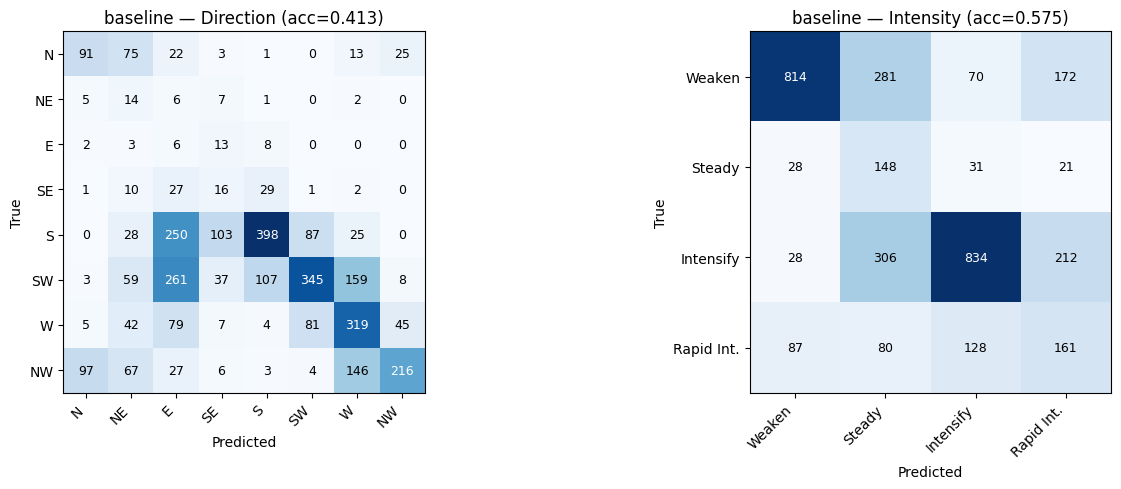

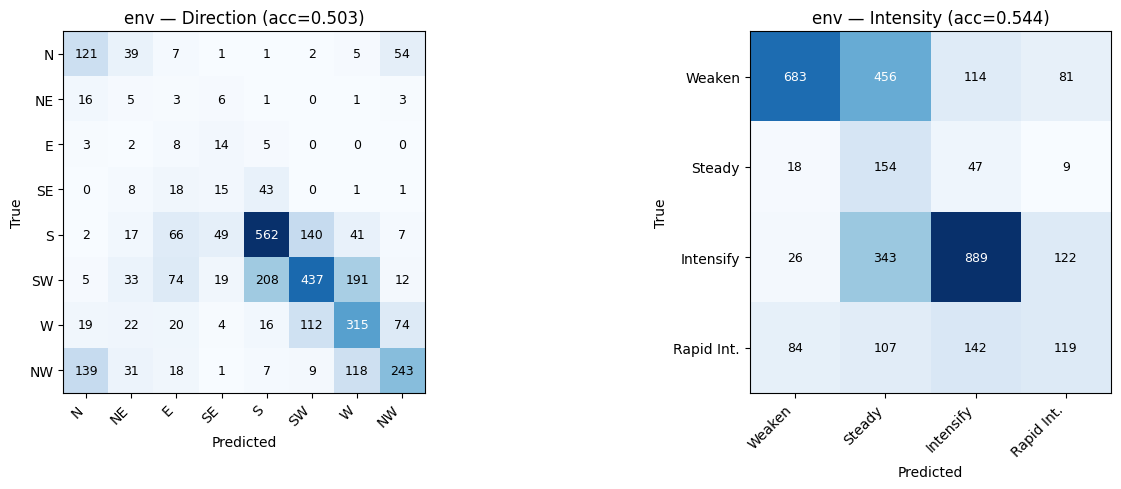

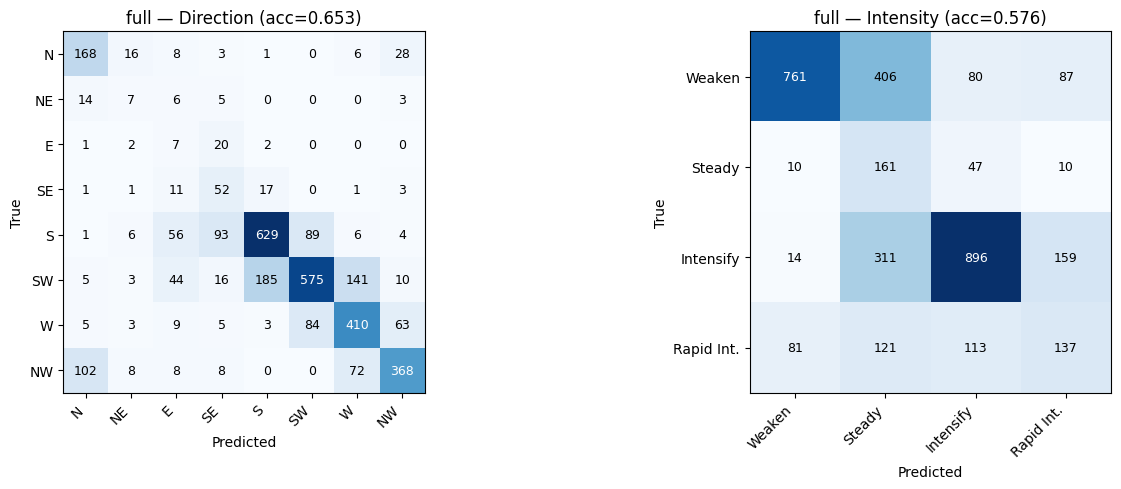

In [15]:
# ── Confusion matrices ──
DIR_LABELS = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
INT_LABELS = ['Weaken', 'Steady', 'Intensify', 'Rapid Int.']

def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    n = len(class_names)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xticks(range(n)); ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    # annotate cells
    thresh = cm.max() / 2
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                    color='white' if cm[i][j] > thresh else 'black', fontsize=9)

for key in ['baseline', 'env', 'full']:
    r = results.get(key)
    if r is None or r['test_res'] is None:
        continue
    t = r['test_res']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    plot_confusion_matrix(t['dir_labels'], t['dir_preds'], DIR_LABELS,
                          f'{key} — Direction (acc={t["dir_acc"]:.3f})', ax1)
    plot_confusion_matrix(t['int_labels'], t['int_preds'], INT_LABELS,
                          f'{key} — Intensity (acc={t["int_acc"]:.3f})', ax2)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'confusion_{key}.png'), dpi=150)
    plt.show()

The Metric: "Dangerous False Negatives"
Tracking critical failures where a storm actually grew (Intensify/Rapid Int.), but the model falsely predicted it would safely Weaken or remain Steady.

Baseline (1-Channel): 501 Dangerous Misses

+Env Model: 560 Dangerous Misses

Full Model (13-Channel 3D CNN): 527 Dangerous Misses

Why did the complex Full Model have more dangerous misses than the simple Baseline?

The Curse of Dimensionality: The baseline model only uses a single spatial channel (z@500). With very few trainable parameters, it easily and efficiently converges on a safe, conservative pattern using our limited historical dataset.

The Data-Hunger of 3D CNNs: Upgrading to the Full Model introduces 12 additional thermodynamic channels processed through 3D Convolutions. This massively explodes the model's parameter count.

The Trade-Off: High-capacity deep learning models require massive amounts of training data to fully optimize. Because the number of recorded historical cyclones is relatively small, the Full Model was slightly "data-starved." It struggled to perfectly tune its millions of parameters, causing a slight regression in baseline stability while trying to learn complex extreme-weather triggers.

## 7. Visualization — Animated Prediction

In [16]:
def create_performance_animation(model, dataset, use_env, use_3d,
                                 num_frames=30, output_gif='eval_animation.gif'):
    model.eval()
    fig, ax = plt.subplots(figsize=(7, 6))
    frames_data = []

    for i in range(min(num_frames, len(dataset))):
        feat1d, env_feat, spatial, dir_y, int_y = dataset[i]
        with torch.no_grad():
            dir_logits, int_logits = model(
                feat1d.unsqueeze(0).to(DEVICE),
                env_feat.unsqueeze(0).to(DEVICE),
                spatial.unsqueeze(0).to(DEVICE),
            )
            dir_pred = dir_logits.argmax(dim=1).item()
            int_pred = int_logits.argmax(dim=1).item()

        # Use the last timestep's Z500 field for display if 3d is available
        if use_3d:
            img = spatial[-1, 3].cpu().numpy()  # z at 500hPa (index 2 in z = index 3 overall)
        else:
            # fallback: show trajectory coords
            img = np.zeros((81, 81))
            for t in range(feat1d.shape[0]):
                lon_idx = int((feat1d[t, 0].item() + 10) * 4) % 81
                lat_idx = int((feat1d[t, 1].item() + 5) * 8) % 81
                img[lat_idx, lon_idx] = t + 1

        frames_data.append((img, dir_y.item(), dir_pred, int_y.item(), int_pred))

    if not frames_data:
        print('No frames to animate')
        return None

    im = ax.imshow(frames_data[0][0], cmap='RdYlBu_r', origin='lower')
    plt.colorbar(im, label='Field value')

    def get_arrow(label):
        angle = np.deg2rad(label * 45)
        return np.cos(angle), np.sin(angle)

    tu, tv = get_arrow(frames_data[0][1])
    pu, pv = get_arrow(frames_data[0][2])
    quiver_true = ax.quiver(40, 40, tu, tv, color='green', scale=5, label='True dir')
    quiver_pred = ax.quiver(40, 40, pu, pv, color='black', scale=5, label='Pred dir', alpha=0.7)
    ax.legend(loc='upper right')

    def animate(i):
        data, true_d, pred_d, true_i, pred_i = frames_data[i]
        im.set_array(data)
        tu, tv = get_arrow(true_d)
        pu, pv = get_arrow(pred_d)
        quiver_true.set_UVC(tu, tv)
        quiver_pred.set_UVC(pu, pv)
        d_ok = true_d == pred_d
        i_ok = true_i == pred_i
        ax.set_title(
            f'Frame {i} | Dir: {DIR_LABELS[true_d]} vs {DIR_LABELS[pred_d]} '
            f'[{"OK" if d_ok else "X"}] | '
            f'Int: {INT_LABELS[true_i]} vs {INT_LABELS[pred_i]} '
            f'[{"OK" if i_ok else "X"}]',
            color='green' if (d_ok and i_ok) else 'red', fontsize=10)
        return [im, quiver_true, quiver_pred]

    anim = animation.FuncAnimation(fig, animate, frames=len(frames_data),
                                   interval=800, blit=True)
    anim.save(output_gif, writer='pillow')
    plt.close()
    print(f'Saved animation to {output_gif}')
    return output_gif


# Animate the best model
best_key = max(
    [k for k in results if results[k] and results[k]['test_res']],
    key=lambda k: results[k]['test_res']['dir_acc']
)
print(f'Animating best model: {best_key}')
r = results[best_key]
gif = create_performance_animation(
    r['model'], r['test_ds'],
    use_env=('env' in best_key or 'full' in best_key),
    use_3d=('full' in best_key),
    output_gif=os.path.join(SAVE_DIR, f'animation_{best_key}.gif'),
)
if gif:
    display(HTML(f'<img src="{gif}" style="width:500px;"/>'))

Animating best model: full
Saved animation to c:\Users\danie\Desktop\Tropical Cyclones\saved_models\animation_full.gif


## 8. Per-Class Metrics

In [17]:
def per_class_metrics(y_true, y_pred, class_names):
    """Compute precision, recall, F1 per class."""
    n = len(class_names)
    rows = []
    for c in range(n):
        tp = sum(1 for t, p in zip(y_true, y_pred) if t == c and p == c)
        fp = sum(1 for t, p in zip(y_true, y_pred) if t != c and p == c)
        fn = sum(1 for t, p in zip(y_true, y_pred) if t == c and p != c)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        support = sum(1 for t in y_true if t == c)
        rows.append({'class': class_names[c], 'precision': prec,
                     'recall': rec, 'f1': f1, 'support': support})
    return pd.DataFrame(rows)


for key in ['baseline', 'env', 'full']:
    r = results.get(key)
    if r is None or r['test_res'] is None:
        continue
    t = r['test_res']
    print(f'\n── {key.upper()} — Direction ──')
    display(per_class_metrics(t['dir_labels'], t['dir_preds'], DIR_LABELS))
    print(f'── {key.upper()} — Intensity ──')
    display(per_class_metrics(t['int_labels'], t['int_preds'], INT_LABELS))


── BASELINE — Direction ──


,class,precision,recall,f1,support
0,N,0.446078,0.395652,0.419355,230
1,NE,0.046980,0.400000,0.084084,35
2,E,0.008850,0.187500,0.016901,32
3,SE,0.083333,0.186047,0.115108,86
4,S,0.722323,0.446689,0.552011,891
5,SW,0.666023,0.352400,0.460922,979
6,W,0.478979,0.548110,0.511218,582
7,NW,0.734694,0.381625,0.502326,566


── BASELINE — Intensity ──


,class,precision,recall,f1,support
0,Weaken,0.850575,0.608826,0.709677,1337
1,Steady,0.181595,0.649123,0.283797,228
2,Intensify,0.784572,0.604348,0.682767,1380
3,Rapid Int.,0.284452,0.353070,0.315068,456



── ENV — Direction ──


...

,class,precision,recall,f1,support
0,Weaken,0.842170,0.511994,0.636830,1334
1,Steady,0.145283,0.675439,0.239130,228
2,Intensify,0.745805,0.644203,0.691291,1380
3,Rapid Int.,0.359517,0.263274,0.303959,452



── FULL — Direction ──


,class,precision,recall,f1,support
0,N,0.565657,0.730435,0.637571,230
1,NE,0.152174,0.200000,0.172840,35
2,E,0.046980,0.218750,0.077348,32
3,SE,0.257426,0.604651,0.361111,86
4,S,0.751493,0.711538,0.730970,884
5,SW,0.768717,0.587334,0.665895,979
6,W,0.644654,0.704467,0.673235,582
7,NW,0.768267,0.650177,0.704306,566


── FULL — Intensity ──


,class,precision,recall,f1,support
0,Weaken,0.878753,0.570465,0.691818,1334
1,Steady,0.161161,0.706140,0.262429,228
2,Intensify,0.788732,0.649275,0.712242,1380
3,Rapid Int.,0.348601,0.303097,0.324260,452


## 9. Per-Year Test Breakdown

In [18]:
# ── Per-year test accuracy (like friend's single-year test, but for all years) ──
# Load the best full model
best_model = CycloneModel(use_env=True, use_3d=True).to(DEVICE)
best_path = os.path.join(SAVE_DIR, 'full_best.pth')
best_model.load_state_dict(torch.load(best_path, weights_only=True))
best_model.eval()

DIR_LABELS = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
INT_LABELS = ['Weaken', 'Steady', 'Intensify', 'Rapid Int.']

print("=" * 60)
print("Per-Year Test Breakdown (2017-2023)")
print("=" * 60)

year_results = {}

for year in range(2017, 2024):
    ds = CycloneDataset(splits=['test'], target_years=[year],
                        use_env=True, use_3d=True)
    if len(ds) == 0:
        print(f"  {year}: No samples found")
        continue
    
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    
    dir_correct, int_correct, total = 0, 0, 0
    dir_preds, dir_labels = [], []
    int_preds, int_labels = [], []
    
    with torch.no_grad():
        for feat1d, env_feat, spatial, dir_y, int_y in loader:
            feat1d = feat1d.to(DEVICE)
            env_feat = env_feat.to(DEVICE)
            spatial = spatial.to(DEVICE)
            
            dir_logits, int_logits = best_model(feat1d, env_feat, spatial)
            dp = dir_logits.argmax(dim=1)
            ip = int_logits.argmax(dim=1)
            
            dir_correct += (dp == dir_y.to(DEVICE)).sum().item()
            int_correct += (ip == int_y.to(DEVICE)).sum().item()
            total += dir_y.size(0)
            
            dir_preds.extend(dp.cpu().tolist())
            dir_labels.extend(dir_y.tolist())
            int_preds.extend(ip.cpu().tolist())
            int_labels.extend(int_y.tolist())
    
    dir_acc = dir_correct / total
    int_acc = int_correct / total
    year_results[year] = {
        'samples': total, 'dir_acc': dir_acc, 'int_acc': int_acc,
        'dir_preds': dir_preds, 'dir_labels': dir_labels,
        'int_preds': int_preds, 'int_labels': int_labels,
    }
    print(f"  {year}: {total:4d} samples | Dir Acc: {dir_acc:.1%} | Int Acc: {int_acc:.1%}")

# Overall
total_samples = sum(r['samples'] for r in year_results.values())
total_dir = sum(r['dir_acc'] * r['samples'] for r in year_results.values()) / total_samples
total_int = sum(r['int_acc'] * r['samples'] for r in year_results.values()) / total_samples
print(f"\n  Overall: {total_samples} samples | Dir Acc: {total_dir:.1%} | Int Acc: {total_int:.1%}")

Per-Year Test Breakdown (2017-2023)
[WP/['test']] 528 samples (env=True, 3d=True, years=[2017])
  2017:  528 samples | Dir Acc: 66.1% | Int Acc: 58.3%
[WP/['test']] 717 samples (env=True, 3d=True, years=[2018])
  2018:  717 samples | Dir Acc: 65.3% | Int Acc: 56.6%
[WP/['test']] 660 samples (env=True, 3d=True, years=[2019])
  2019:  660 samples | Dir Acc: 65.6% | Int Acc: 64.5%
[WP/['test']] 459 samples (env=True, 3d=True, years=[2020])
  2020:  459 samples | Dir Acc: 69.3% | Int Acc: 57.5%
[WP/['test']] 613 samples (env=True, 3d=True, years=[2021])
  2021:  613 samples | Dir Acc: 61.0% | Int Acc: 53.5%
[WP/['test']] 146 samples (env=True, 3d=True, years=[2022])
  2022:  146 samples | Dir Acc: 70.5% | Int Acc: 50.0%
[WP/['test']] 271 samples (env=True, 3d=True, years=[2023])
  2023:  271 samples | Dir Acc: 63.1% | Int Acc: 55.4%

  Overall: 3394 samples | Dir Acc: 65.3% | Int Acc: 57.6%


### Cross-Model Comparison

| Model | Channels | Params | Dir Acc | Int Acc |
|-------|----------|--------|---------|---------|
| Baseline (1D only) | — | ~50k | 41.3% | 57.5% |
| + Env-Data | — | ~80k | 50.3% | 54.4% |
| **Full (13ch)** | **13** | **3.85M** | **65.3%** | **57.6%** |
| 1ch Ablation (z@500) | 1 | ~500k | 66.5% | 66.75% |

The 1-channel ablation (z@500 only) achieves comparable direction accuracy to the full 13-channel model, confirming that geopotential height at 500 hPa is the dominant feature for track prediction.

The higher direction prediction for the simpler 1 channel model can come due to the fact that the 13 channel model has too many parameters for the small number of training data.

 The better intensity of the 1channel model is not useful for comparison as the 2 models were trained differently with the 1 channel one not using reweighting for the rare dangerous cases prediction.

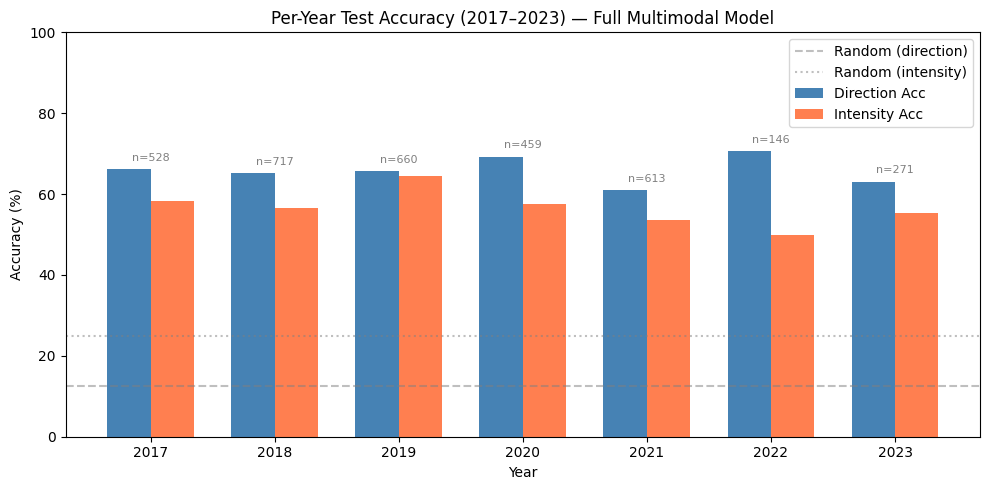

Saved to c:\Users\danie\Desktop\Tropical Cyclones\saved_models\per_year_accuracy.png


In [19]:
# ── Per-year accuracy bar chart ──
years = sorted(year_results.keys())
dir_accs = [year_results[y]['dir_acc'] * 100 for y in years]
int_accs = [year_results[y]['int_acc'] * 100 for y in years]
samples = [year_results[y]['samples'] for y in years]

fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(years))
width = 0.35

bars1 = ax1.bar(x - width/2, dir_accs, width, label='Direction Acc', color='steelblue')
bars2 = ax1.bar(x + width/2, int_accs, width, label='Intensity Acc', color='coral')

# Add sample counts on top
for i, (d, s) in enumerate(zip(dir_accs, samples)):
    ax1.text(i, max(d, int_accs[i]) + 2, f'n={s}', ha='center', fontsize=8, color='gray')

ax1.set_xlabel('Year')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Per-Year Test Accuracy (2017–2023) — Full Multimodal Model')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.set_ylim(0, 100)
ax1.axhline(y=12.5, color='gray', linestyle='--', alpha=0.5, label='Random (direction)')
ax1.axhline(y=25.0, color='gray', linestyle=':', alpha=0.5, label='Random (intensity)')
ax1.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'per_year_accuracy.png'), dpi=150)
plt.show()
print(f"Saved to {os.path.join(SAVE_DIR, 'per_year_accuracy.png')}")